In [1]:
from sklearn.metrics.pairwise import pairwise_distances
import os
import pickle
from dotenv import load_dotenv
import matplotlib.pyplot as plt
import numpy as np
import glob
import easyocr
import cv2
from imutils.video import FileVideoStream
from datetime import datetime, time, timedelta

In [2]:
load_dotenv()

True

In [3]:
video_folder = os.environ.get("VIDEO_FILES")
tracks_folder = os.environ.get("TRACKS_OUTPUT")

In [4]:
video_files = sorted(glob.glob(os.path.join(
    video_folder, f"RecM0A_DST20250807_*_*_0_*_*.mp4")))

track_files = sorted(glob.glob(os.path.join(
    tracks_folder, f"2025-08-07-tracks-class-3-clip-*.pkl")))

In [5]:
tracks = {}
for i in range(len(track_files)):
    t = os.path.join(tracks_folder, f"{track_files[i]}")
    t1 = pickle.load(open(t, 'rb'))
    tracks[i] = t1

C:\Users\BDDea\AppData\Local\Temp\ipykernel_3580\3820125882.py:4: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  t1 = pickle.load(open(t, 'rb'))


In [6]:
def new_fish_mid(track):
    ''' 
    Returns midpoint of each fish at each time in each file

        Args:
            track (dict): gives fish with corresponding time stamps and location
                keys: tag number for fish
                values (dict): gives time stamps and location and size of bounding box
                    keys: time stamps (frame number)
                    values (list): top left coordinates of bounding box followed by the width and height of the box
        Returns:
            track (dict): same format as the parameter, only with xmidpoint for each bounding box
                keys: tag number for fish
                values (dict): gives time stamps and x midpoint of bounding box
                    keys: time stamps
                    values: x midpoint of bounding box
    '''
    for tag in track.keys():
        for time in track[tag].keys():
            if len(track[tag][time]) == 4:
                x_min, y_min, width, height = track[tag][time]
                track[tag][time][0] = x_min + width/2
                # track[tag][time][1] = y_min + height/2
                track[tag][time] = track[tag][time][0].tolist()
    return track

In [7]:
for file in tracks.keys():
    tracks[file] = new_fish_mid(tracks[file])

In [8]:
for i in range(len(tracks)):
    if i < 92:
        del tracks[i]

In [9]:
def crossing_times(tag, line, leftright):
    ''' 
    Returns the crossing time for a specified fish

        Parameters:
            tag (dict): gives coordinate for fish at respective time stamps
                keys: time stamp
                values: x midpoint for bounding box (from fish_mid function)
            line (int): x-value of vertical line for crossing
        Returns:
            times (list): list of frame count number to give times that fish crossed line
    '''
    times = []
    for time in tag.keys():
        if time+1 in tag.keys():
            if leftright == True:
                if tag[time] < line:
                    if tag[time+1] >= line:
                        times.append(time)
            else:
                if tag[time] >= line:
                    if tag[time+1] < line:
                        times.append(time)
    if times != []:
        return times


def file_fish_cross(tracks, line):
    ''' 
    Returns the files in which fish cross a vertical line

        Parameters:
            tracks (dict): gives file number, fish tag, time, and location for files
                keys: file number
                values (dict): fish tag numbers with respective time and x midpoint location
                    As given by fish_mid function.
                    keys: fish tag number
                    values (dict): x midpoint for each frame number
                        keys: frame number to give time
                        values: x-midpoint of boudning box
            line (int): x-value of vertical line for measuring crossing
        Returns:
            lr (dict): gives crossing times for each fish going left to right.
                keys: file number
                values (dict): gives fish and crossing time for each file 
                    keys: fish tag number
                    values (list): frame number for crossing times
            rl (dict):gives crossing times for each fish going right to left.
                keys: file number
                values (dict): gives fish and crossing time for each file 
                    keys: fish tag number
                    values (list): frame number for crossing times
    '''
    lr = {}
    rl = {}
    for file in tracks.keys():
        for tag in tracks[file].keys():
            lr_crossing = crossing_times(
                tracks[file][tag], line=line, leftright=True)
            if lr_crossing:
                if file not in lr.keys():
                    lr[file] = {}
                lr[file][tag] = lr_crossing
            rl_crossing = crossing_times(
                tracks[file][tag], line=line, leftright=False)
            if rl_crossing:
                if file not in rl.keys():
                    rl[file] = {}
                rl[file][tag] = rl_crossing
    return lr, rl

In [41]:
left_right, right_left = file_fish_cross(tracks, 1500)

In [11]:
reader = easyocr.Reader(['en'])

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


In [ ]:
def new_convert2(video_file, x_fac, y_fac):
    '''
    Gives the time of day in seconds for each of the frames in a video

        Args:
            video_file: mp4 file of the salmon
            x_fac (int): specifies the scaling factor for the x-axis
            y_fac (int): specifies the scaling factor for the y-axis
        Returns:
            output (list): list of times in seconds, with index + 1 corresponding to the frame number
    '''
    fvs = FileVideoStream(video_file).start()
    output = []
    frame_count = 0
    while fvs.more():
        frame = fvs.read()
        if frame is None:
            break
        frame_count += 1
        frame = frame[20:76, 1443:1520]
        if frame_count == 1:
            t1 = datetime(2025, 8, 1, int(video_file[82:84]), int(
                video_file[84:86]), int(video_file[86:88]))
            output.append(t1)
            continue
        frame = cv2.resize(frame, None, fx=x_fac, fy=y_fac)
        secs = str(t1.second).zfill(2) + \
            str((t1 + timedelta(seconds=1)).second).zfill(2)
        second = reader.readtext(frame, allowlist=secs, detail=0)
        if second:
            if second[0] == secs[2:]:
                if frame_count > 15:
                    if output[-1] == output[-14]:
                        t1 += timedelta(seconds=1)
                else:
                    t1 += timedelta(seconds=1)
        else:
            if frame_count >= 16:
                if output[-1] == output[-15]:
                    t1 += timedelta(seconds=1)
        output.append(t1)
    return output

In [ ]:
def time_replace(direction_data_file, output):
    '''
    Replaces frame number with corresponding time value in seconds

        Args:
            direction_data_file (dict): gives list of crossing times for each fish that crossed the line
                As returned for each file from file_fish_cross function
                keys: fish tag number
                values (list): list of frame number for crossing times
            output (list): list of time stamps in seconds for the file
                As returned by time_converter() function
        Returns:
            new_data (dict): same structure as direction_data_file but with time values in seconds
    '''
    new_data = {}
    for tag, times in direction_data_file.items():
        new_data[tag] = []
        for time in times:
            if output[time-1] not in new_data[tag]:
                stamp = output[time-1]
                new_data[tag].append(3600 * stamp.hour +
                                     60 * stamp.minute + stamp.second)
    return new_data

In [ ]:
def direction_time_replace(lr, rl, video_files, x_fac, y_fac):
    '''Uses time_replace function for all files in the crossing data

        Args:
            lr (dict): gives files where fish crossed the line left to right
                As returned from file_fish_cross fuction
                keys: file number
                values (dict): fish tag number and respective crossing times
                    keys: fish tag number
                    values: list of crossing times
            rl (dict): gives files where fish crossed the line right to left
                As returned from file_fish_cross function
                keys: file number
                values (dict): fish tag number and respective crossing times
                    keys: fish tag number
                    values: list of crossing times
            video_files (list): video files corresponding to the tracks
            x_fac (int): scale factor for x-axis of image
            y_fac (int): scale factor for y-axis of image
        Returns:
            lr (dict): same structure as parameter but with times in seconds
            rl (dict): same structure as parameter but with times in seconds
    '''
    files = []
    for file in lr.keys():
        files.append(file)
        # output = time_converter(video_files[file], x_fac, y_fac)
        output = new_convert2(video_files[file], x_fac, y_fac)
        left_right[file] = time_replace(left_right[file], output)
        if file in rl.keys():
            right_left[file] = time_replace(right_left[file], output)
    for file in rl.keys():
        if file in files:
            continue
        files.append(file)
        # output = time_converter(video_files[file], x_fac, y_fac)
        output = new_convert2(video_files[file], x_fac, y_fac)
        right_left[file] = time_replace(right_left[file], output)
    return lr, rl

In [16]:
def full_day(lr, rl):
    '''
    Combines direction data from all of the files for a day

        Args:
            lr (dict): gives fish and their crossing times from left to right in seconds for each file with a fish that crosses the line
                keys: file number
                values (dict): gives fish tag and its crossing times
                    keys: fish tag number
                    values (list): list of crossing times in seconds
            rl (dict): gives fish and their crossing times from right to left in seconds for each file containing a fish that crosses the line
                keys: file number
                values: fish tag with its crossing times
                    keys: fish tag number
                    values: list of crossing times in seconds
        Returns:
            full_lr (dict): fish with their respective crossing times in seconds
                keys: fish tag number
                values: list of crossing times in seconds
            full_rl (dict): fish with their respective crossing times in seconds
                keys: fish tag number
                values: list of crossing times in seconds
    '''
    full_lr = {}
    full_rl = {}
    for file in lr.keys():
        for tag, times in lr[file].items():
            full_lr[tag] = times
    for file in rl.keys():
        for tag, times in rl[file].items():
            full_rl[tag] = times
    return full_lr, full_rl

In [24]:
from dbscan1d.core import DBSCAN1D

In [ ]:
def dbscan_dist(direction_data, proximity):
    '''
    Uses DBSCAN1 to get fish groups of given direction data with specified proximity

        Args:
            direction_data (dict): fish tags with their respective crossing times for an entire day
                keys: fish tag number
                values: list of crossing times in seconds
            proximity (int): specifies how close in time classifies a group
        Returns:
            groups (list): list of all groups with their respective fish
    '''
    fishes = []
    all_times = []
    for fish, times in direction_data.items():
        for time in times:
            fishes.append(fish)
            all_times.append(time)
    all_times = np.array(all_times)
    dbs = DBSCAN1D(eps=proximity, min_samples=2)
    labels = dbs.fit_predict(all_times)
    groups = []
    for label in set(labels):
        if label == -1:
            continue
        group = []
        for i in range(len(labels)):
            if labels[i] == label:
                if fishes[i] not in group:
                    group.append(fishes[i])
        groups.append(group)
    return groups

c:\Users\BDDea\anaconda3\envs\trial_env\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


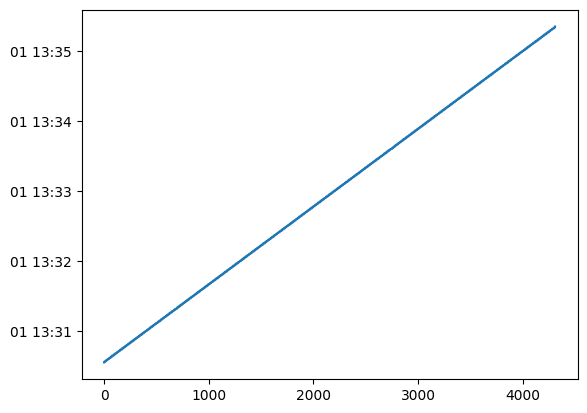

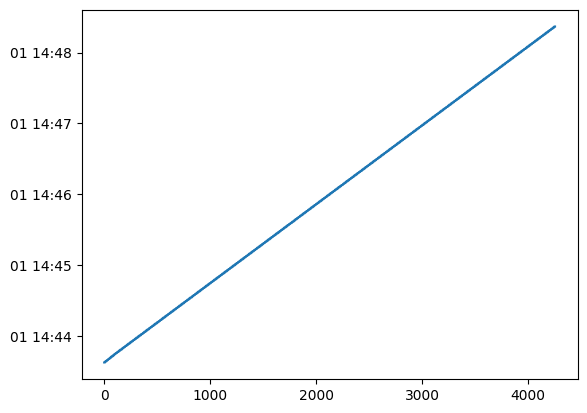

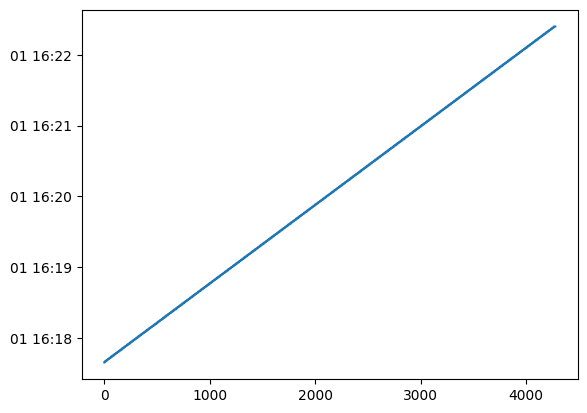

In [ ]:
# if you don't rerun left_right and right_left it will give an error because the indices will be out of range in time_replace
left_right, right_left = file_fish_cross(tracks, 1500)
count = 0
files = []
for file in left_right.keys():
    files.append(file)
    if count >= 3:
        break
    count += 1
    # take out the -92 in the real deal. Just for these limited videos
    # output = time_converter(video_files[file-92], 0.7, 0.7)
    output = new_convert2(video_files[file], 0.7, 0.7)
    plt.plot(output)
    plt.show()
    left_right[file] = time_replace(left_right[file], output)
    if file in right_left.keys():
        right_left[file] = time_replace(right_left[file], output)

In [52]:
new_lr = {}
new_rl = {}

for file in files[:-1]:
    new_lr[file] = left_right[file]
    print(left_right[file])
    new_rl[file] = right_left[file]
    print(right_left[file])

{5079: [48775]}
{5079: [48774]}
{5378: [53143]}
{5396: [53200]}
{5773: [58792]}
{5771: [58750]}


In [53]:
llr, rrl = full_day(new_lr, new_rl)
print(llr)
print(rrl)

{5079: [48775], 5378: [53143], 5773: [58792]}
{5079: [48774], 5396: [53200], 5771: [58750]}


In [ ]:
rrl = {5079: [48774], 5396: [53200], 5771: [58750], 5800: [59267], 5801: [59264], 5805: [
    59365], 5807: [59370], 5810: [59367], 5820: [59420], 5822: [59420], 5826: [59493]}
llr = {5079: [48775], 5378: [53143], 5773: [58792], 5808: [59370]}

In [60]:
print(dbscan_dist(rrl, 6))
print(dbscan_dist(llr, 5000))

[-1 -1 -1]
[]
[ 0  0 -1]
[[5079, 5378]]
